In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from kapre import STFT, Magnitude, MagnitudeToDecibel, ApplyFilterbank

# Change working directory to the root of the project to be able to import the necessary modules
import os
os.chdir('../.')
from datasets.load_data import load_dataset

%load_ext autoreload
%autoreload 2

gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

2024-12-03 13:04:26.505048: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-12-03 13:04:26.539886: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-12-03 13:04:26.539909: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-12-03 13:04:26.540703: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-12-03 13:04:26.545952: I tensorflow/core/platform/cpu_feature_guar

# Speech Commands

In [2]:
# params = {'input_shape': [6000, 1], 'classes_filter': [], 'num_classes': 12}
ds_train, ds_val, ds_test, class_weights = load_dataset(dataset_name="speech_commands")

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'NoneType' object has no attribute '__dict__'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


2024-12-02 14:41:49.994950: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-12-02 14:41:50.044881: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-12-02 14:41:50.046009: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'NoneType' object has no attribute '__dict__'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'NoneType' object has no attribute '__dict__'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'NoneType' object has no attribute '__dict__'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'NoneType' object has no attribute '__dict__'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'NoneType' object has no attribute '__dict__'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'NoneType' object has no attribute '__dict__'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'NoneType' object has no attribute '__dict__'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


In [4]:
# create model, first STFT block, then EfficientNetB0
model = tf.keras.models.Sequential()
model.add(STFT(input_shape=[6000, 1], n_fft=512, hop_length=32, name='stft'))
model.add(Magnitude())
model.add(MagnitudeToDecibel())
kwargs = {
    'sample_rate': 6000,
    'n_freq': 512 // 2 + 1,
    'n_mels': 128,
    'f_min': 0,
    'f_max': 3000,
    'htk': False,
    'norm': 'slaney',
}
model.add(ApplyFilterbank(type='mel', filterbank_kwargs=kwargs, data_format='channels_last'))

# add layer that duplicates the input to 3 channels
model.add(tf.keras.layers.Lambda(lambda x: tf.tile(x, [1, 1, 1, 3])))

efficientnet = tf.keras.applications.EfficientNetB0(
    include_top=False, 
    weights='imagenet', 
    input_shape=(172, 128, 3),
    pooling='avg'
)

model.add(efficientnet)
model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dense(12, activation='softmax'))

In [4]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

initial_learning_rate = 0.001 
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate,
    decay_steps=0.2,
    decay_rate=0.8,
    staircase=True)

lr_callback = tf.keras.callbacks.LearningRateScheduler(schedule=lr_schedule, verbose=0)

history = model.fit(ds_train.batch(128), validation_data=ds_val.batch(128), epochs=10, class_weight=class_weights, callbacks=[lr_callback])

2024-11-20 10:33:49.446107: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


Epoch 1/10


2024-11-20 10:34:06.945405: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential/efficientnetb0/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2024-11-20 10:34:13.150368: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8700
2024-11-20 10:34:14.240835: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2024-11-20 10:34:15.974743: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7fe0642da490 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-11-20 10:34:15.974801: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce GTX 1080 Ti, Compute Capability 6.1
2024-11-20 10:34:15.996158: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling

669/669 [==============================] - 726s 1s/step - loss: 0.4561 - accuracy: 0.7525 - val_loss: 2.5124 - val_accuracy: 0.0120 - lr: 0.0010
Epoch 2/10
669/669 [==============================] - 696s 1s/step - loss: 0.1467 - accuracy: 0.9071 - val_loss: 0.4917 - val_accuracy: 0.8336 - lr: 3.2768e-04
Epoch 3/10
669/669 [==============================] - 694s 1s/step - loss: 0.0867 - accuracy: 0.9412 - val_loss: 0.2807 - val_accuracy: 0.9131 - lr: 1.0737e-04
Epoch 4/10
669/669 [==============================] - 681s 1s/step - loss: 0.0652 - accuracy: 0.9503 - val_loss: 0.1487 - val_accuracy: 0.9502 - lr: 3.5184e-05
Epoch 5/10
669/669 [==============================] - 681s 1s/step - loss: 0.0583 - accuracy: 0.9555 - val_loss: 0.1425 - val_accuracy: 0.9516 - lr: 1.1529e-05
Epoch 6/10
669/669 [==============================] - 677s 1s/step - loss: 0.0567 - accuracy: 0.9561 - val_loss: 0.1445 - val_accuracy: 0.9513 - lr: 3.7779e-06
Epoch 7/10
669/669 [==============================] - 6

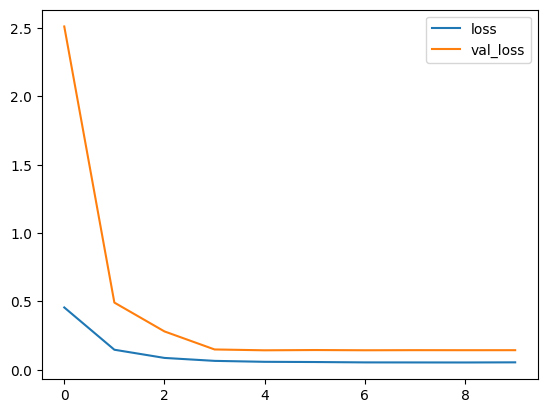

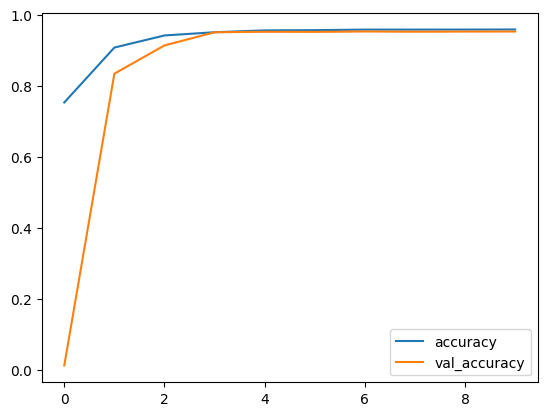

In [22]:
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.legend()
plt.show()

In [12]:
model.save("effnet_speech_commands_trained.keras")

In [4]:
m = tf.keras.models.load_model("effnet_speech_commands_trained.keras", custom_objects={'STFT': STFT,
                                                             'Magnitude': Magnitude,
                                                             'ApplyFilterbank': ApplyFilterbank,
                                                             'MagnitudeToDecibel': MagnitudeToDecibel}, safe_mode=False)

m.evaluate(ds_val.batch(128))

2024-11-22 09:14:21.667189: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2024-11-22 09:14:22.978336: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8700
2024-11-22 09:14:23.854716: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


79/79 [==============================] - 63s 721ms/step - loss: 0.1434 - accuracy: 0.9523


[0.1433885097503662, 0.9522866606712341]

# EMG AIROB

In [7]:
ds_train, ds_val, ds_test, _ = load_dataset(dataset_name="emg_airob")

FileNotFoundError: [Errno 2] No such file or directory: '/data_slow2/du92wufe/EvoNAS/datasets/data/emg_airob/merged_EMG_new_raw_data.csv'

In [3]:
class InterpolationLayer(tf.keras.layers.Layer):
    def __init__(self, target_size, method='bilinear', **kwargs):
        super(InterpolationLayer, self).__init__(**kwargs)
        self.target_size = target_size
        self.method = method

    def call(self, inputs):
        return tf.image.resize(inputs, self.target_size, method=self.method)
    
class ZeroPadToShape(tf.keras.layers.Layer):
    def __init__(self, target_shape, **kwargs):
        """
        Initialize the ZeroPadToShape layer.
        
        Args:
            target_shape (tuple): Desired output shape (Batch, Height, Width, Channels).
                                  Batch and channel dimensions should match the input.
        """
        super(ZeroPadToShape, self).__init__(**kwargs)
        self.target_shape = target_shape

    def call(self, inputs):
        input_shape = tf.shape(inputs)
        batch_size, h, w, c = input_shape[0], input_shape[1], input_shape[2], input_shape[3]
        target_h, target_w = self.target_shape[1], self.target_shape[2]

        # Calculate padding for height and width
        pad_h = tf.maximum(0, target_h - h)
        pad_w = tf.maximum(0, target_w - w)

        pad_top = pad_h // 2
        pad_bottom = pad_h - pad_top
        pad_left = pad_w // 2
        pad_right = pad_w - pad_left

        # Apply zero padding: ((top, bottom), (left, right))
        paddings = [[0, 0], [pad_top, pad_bottom], [pad_left, pad_right], [0, 0]]
        return tf.pad(inputs, paddings, mode='CONSTANT', constant_values=0)

In [ ]:
# ds_train, ds_val, ds_test, _ = get_datasets(dataset_name="emg_airob")

model = tf.keras.models.Sequential()


model.add(tf.keras.layers.Input(shape=(20, 16, 1)))
# model.add(ZeroPadToShape((1, 64, 64, 1)))
model.add(InterpolationLayer((64, 64)))

model.add(tf.keras.layers.Lambda(lambda x: tf.tile(x, [1, 1, 1, 3])))

efficientnet = tf.keras.applications.EfficientNetB0(
    include_top=False, 
    weights='imagenet', 
    input_shape=(64, 64, 3),
    pooling='avg'
)

model.add(efficientnet)
model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dense(7, activation='softmax'))

# model.summary()

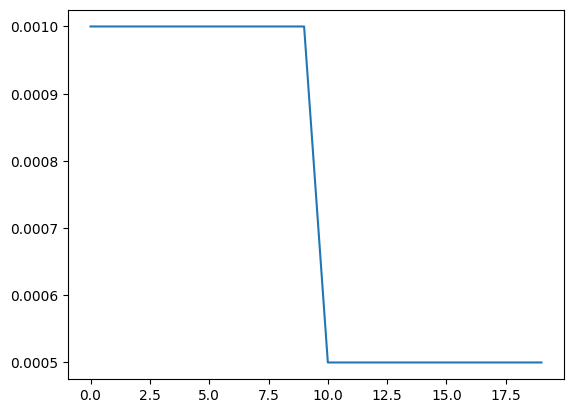

In [8]:
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    0.001,
    decay_steps=10,
    decay_rate=0.5,
    staircase=True)
values = []
for i in range(20):
    values.append(lr_schedule(i))
    
plt.plot(values)

In [21]:

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

initial_learning_rate = 0.001
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate,
    decay_steps=10,
    decay_rate=0.5,
    staircase=True)

lr_callback = tf.keras.callbacks.LearningRateScheduler(schedule=lr_schedule, verbose=0)

history = model.fit(ds_train.batch(64), validation_data=ds_val.batch(64), epochs=20, callbacks=[lr_callback])

Epoch 1/50


KeyboardInterrupt: 

In [ ]:
plt.figure(figsize=(3, 3))
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()

In [ ]:
plt.figure(figsize=(3, 3))
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()

In [8]:
model.save("effnet_emg_airob_trained.keras")

## Cifar10

In [2]:
ds_train, ds_val, ds_test, _ = load_dataset(dataset_name="cifar10")

model = tf.keras.models.Sequential()

efficientnet = tf.keras.applications.EfficientNetB0(
    include_top=False, 
    weights=None, 
    input_shape=(32, 32, 3),
    pooling='avg'
)

model.add(efficientnet)
model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dense(10, activation='softmax'))

# model.summary()

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'NoneType' object has no attribute '__dict__'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


2024-12-03 13:05:09.865743: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-12-03 13:05:09.866918: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-12-03 13:05:09.868004: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'NoneType' object has no attribute '__dict__'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'NoneType' object has no attribute '__dict__'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'NoneType' object has no attribute '__dict__'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'NoneType' object has no attribute '__dict__'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'NoneType' object has no attribute '__dict__'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'NoneType' object has no attribute '__dict__'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'NoneType' object has no attribute '__dict__'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


In [29]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

initial_learning_rate = 0.01
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate,
    decay_steps=30,
    decay_rate=0.5,
    staircase=True)

lr_callback = tf.keras.callbacks.LearningRateScheduler(schedule=lr_schedule, verbose=0)
history = model.fit(ds_train.batch(64), validation_data=ds_val.batch(64), epochs=75, callbacks=[lr_callback])

Epoch 1/75


2024-12-02 17:40:11.826071: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_9/efficientnetb0/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


704/704 [==============================] - 81s 42ms/step - loss: 2.0554 - accuracy: 0.1879 - val_loss: 2.1616 - val_accuracy: 0.1988 - lr: 0.0100
Epoch 2/75
704/704 [==============================] - 28s 39ms/step - loss: 1.9673 - accuracy: 0.2212 - val_loss: 2.3151 - val_accuracy: 0.2006 - lr: 0.0100
Epoch 3/75
704/704 [==============================] - 28s 39ms/step - loss: 1.9662 - accuracy: 0.2269 - val_loss: 1.9937 - val_accuracy: 0.2436 - lr: 0.0100
Epoch 4/75
704/704 [==============================] - 28s 39ms/step - loss: 1.8414 - accuracy: 0.2785 - val_loss: 1.9635 - val_accuracy: 0.2666 - lr: 0.0100
Epoch 5/75
704/704 [==============================] - 27s 39ms/step - loss: 2.0713 - accuracy: 0.1851 - val_loss: 2.1771 - val_accuracy: 0.1786 - lr: 0.0100
Epoch 6/75
704/704 [==============================] - 27s 39ms/step - loss: 1.9441 - accuracy: 0.2328 - val_loss: 1.9718 - val_accuracy: 0.2480 - lr: 0.0100
Epoch 7/75
704/704 [==============================] - 28s 40ms/step -

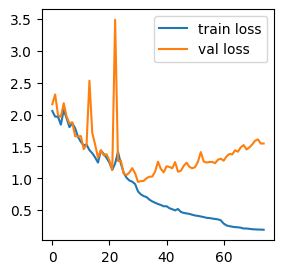

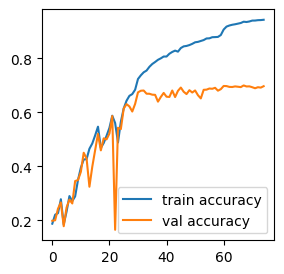

In [30]:
# plot history
plt.figure(figsize=(3, 3))
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()

plt.figure(figsize=(3, 3))
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()

In [6]:
import numpy as np
import matplotlib.pyplot as plt

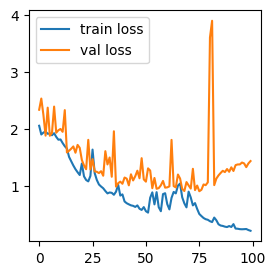

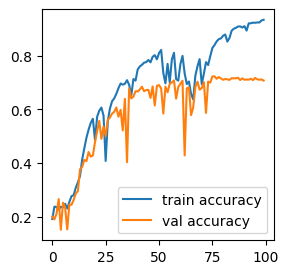

In [7]:
history = np.load("history_cifar10.npy", allow_pickle=True).item()

# plot history
plt.figure(figsize=(3, 3))
plt.plot(history['loss'], label='train loss')
plt.plot(history['val_loss'], label='val loss')
plt.legend()

plt.figure(figsize=(3, 3))
plt.plot(history['accuracy'], label='train accuracy')
plt.plot(history['val_accuracy'], label='val accuracy')
plt.legend()

## DaLiAc Dataset

In [ ]:
ds_train, ds_val, ds_test, _ = get_datasets(dataset="daliac", params=params)